# 00 – Raw Data Overview

This notebook loads the raw dataset `masterdapt_merged.parquet` and provides a basic overview:
dimensions, column types, missing values, and distribution of the main variables.

**Input:** `../data/masterdapt_merged.parquet`  
**Output:** none – exploratory notebook, no data modifications.

## 1. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

PROJECT_DIR = os.path.dirname(os.getcwd())
sys.path.append(PROJECT_DIR)

# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Loading the dataset

In [2]:
DATA_PATH = '../data/selected_schema_data.parquet'

df = pd.read_parquet(DATA_PATH)

print(f'Rows:     {df.shape[0]:,}')
print(f'Columns:  {df.shape[1]:,}')

Rows:     4,579
Columns:  63


## 3. General structure

Quick overview of the first rows and data types.

In [3]:
# First 5 rows – useful to understand the value format
df.head()

,randomized_pop,mnppid,mnpaid,mnpctrid,mnpctrname,centre,mnpcname,mnp_regimen_gr,cec_barc235_335d,cec_cvdeath_335d,cec_mi_335d,cec_stroke_335d,cec_bleed_335d,cec_barc2_335d,cec_barc3_335d,cec_barc35_335d,cec_revasc_335d,fup_other,rand_oac12,cancer,prec_priorbleed,p_bleed,rand_ster_nsaid,rand_anemia,fup_nitrates,...,prec_hb,pci_creatinine_pre,prec_wbc,bmi,pci_platelvol_pre,prior_mi,bp_sys,contrast,pci_platelvol_ldis,prior_pci,prec_creatinine,pci_tropo_ldis,height,fup_ccs,afib,alcohol,diabetes,geography,p_bleed_action1,proir_avs_yn,acs_last_pci,acs,smoker,gender,race
0,randomised,15063,0634-031-01-0002,341,"634 - The Netherlands, Rotterdam, Maasstad Zie...",031-01,The Netherlands,prolonged DAPT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,15.78,91.00,8.50,23.42,NaN,0,155.00,225.00,NaN,2,91.00,NaN,175.00,<NA>,no,unknown - the patient does not want to answer,no,Europe,__none__,NaN,Stable angina,Stable angina,yes - previous smoker,Male,Caucasian origin
1,randomised,15064,0634-031-01-0003,341,"634 - The Netherlands, Rotterdam, Maasstad Zie...",031-01,The Netherlands,abbreviated DAPT,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,13.36,80.00,6.70,27.15,NaN,0,152.00,220.00,NaN,0,80.00,NaN,169.50,<NA>,no,yes - less than eight beers or equivalent per ...,no,Europe,__none__,no,Stable angina,Stable angina,yes - previous smoker,Male,Caucasian origin
2,randomised,15081,0634-031-01-0005,341,"634 - The Netherlands, Rotterdam, Maasstad Zie...",031-01,The Netherlands,prolonged DAPT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,15.46,NaN,8.20,23.52,NaN,0,133.00,130.00,NaN,0,66.00,NaN,167.50,<NA>,no,never,no,Europe,__none__,NaN,Stable angina,Stable angina,yes - previous smoker,Female,Caucasian origin
3,randomised,15222,0634-031-01-0008,341,"634 - The Netherlands, Rotterdam, Maasstad Zie...",031-01,The Netherlands,prolonged DAPT,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,...,14.01,45.00,7.00,27.11,NaN,2,103.00,60.00,NaN,2,45.00,NaN,176.00,<NA>,no,never,no,Europe,Previous bleeding episode which required hos...,no,ACS NSTEMI,ACS NSTEMI,yes - current smoker,Female,Caucasian origin
4,randomised,15223,0634-031-01-0009,341,"634 - The Netherlands, Rotterdam, Maasstad Zie...",031-01,The Netherlands,prolonged DAPT,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,...,13.36,77.00,7.10,28.06,NaN,0,159.00,270.00,NaN,0,77.00,NaN,172.00,<NA>,no,never,no,Europe,__none__,NaN,Stable angina,Stable angina,no - never smoked,Male,Caucasian origin


In [4]:
# Summary of data types and memory usage
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4579 entries, 0 to 4578
Data columns (total 63 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   randomized_pop      4579 non-null   object  
 1   mnppid              4579 non-null   int32   
 2   mnpaid              4579 non-null   object  
 3   mnpctrid            4579 non-null   int16   
 4   mnpctrname          4579 non-null   object  
 5   centre              4579 non-null   object  
 6   mnpcname            4579 non-null   object  
 7   mnp_regimen_gr      4579 non-null   object  
 8   cec_barc235_335d    4579 non-null   Int8    
 9   cec_cvdeath_335d    4579 non-null   Int8    
 10  cec_mi_335d         4579 non-null   Int8    
 11  cec_stroke_335d     4579 non-null   Int8    
 12  cec_bleed_335d      4579 non-null   Int8    
 13  cec_barc2_335d      4579 non-null   Int8    
 14  cec_barc3_335d      4579 non-null   Int8    
 15  cec_barc35_335d     4579 non-null   In

In [5]:
# Column count by data type
df.dtypes.value_counts().rename('n_columns').to_frame()

,n_columns
Int8,26
float64,16
object,6
int16,2
int32,1
category,1
category,1
category,1
category,1
category,1


## 4. Column groups

Columns can be grouped by prefix:

| Prefix | Description |
|--------|-------------|
| *(none)* | Baseline demographic and clinical data |
| `scr_` | Screening criteria |
| `rand_` | Variables at randomisation |
| `prec_` | PRECISE-DAPT score |
| `cci_` | Charlson Comorbidity Index |
| `fup_` | Pharmacological and clinical follow-up |
| `pci_` | PCI procedural data |
| `cec_` | Clinical endpoints (outcomes at 335 days) |

In [6]:
# Count number of columns per prefix
prefixes = ['scr_', 'rand_', 'prec_', 'cci_', 'fup_', 'pci_', 'cec_']

col_groups = {}
for p in prefixes:
    cols = [c for c in df.columns if c.startswith(p)]
    col_groups[p] = len(cols)

# Columns without a known prefix = baseline variables
tagged = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]
col_groups['(baseline)'] = len(df.columns) - len(tagged)

pd.Series(col_groups, name='n_columns').sort_values(ascending=False).to_frame()

,n_columns
(baseline),35
cec_,9
pci_,7
fup_,5
prec_,4
rand_,3
cci_,0
scr_,0


## 5. Missing values

Identification of columns with missing data and their percentage.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_df = missing_df[missing_df['n_missing'] > 0].sort_values('pct_missing', ascending=False)

print(f'Columns with at least one missing value: {len(missing_df)} out of {df.shape[1]}')
missing_df

Columns with at least one missing value: 17 out of 63


,n_missing,pct_missing
fup_ccs,4382,95.70
pci_platelvol_ldis,3273,71.50
fup_nyha,2736,59.80
pci_platelvol_pre,2550,55.70
pci_tropo_ldis,2544,55.60
pci_tropo_pre,2257,49.30
pci_glycemia,1290,28.20
pci_platel_pre,892,19.50
pci_creatinine_pre,832,18.20
proir_avs_yn,459,10.00


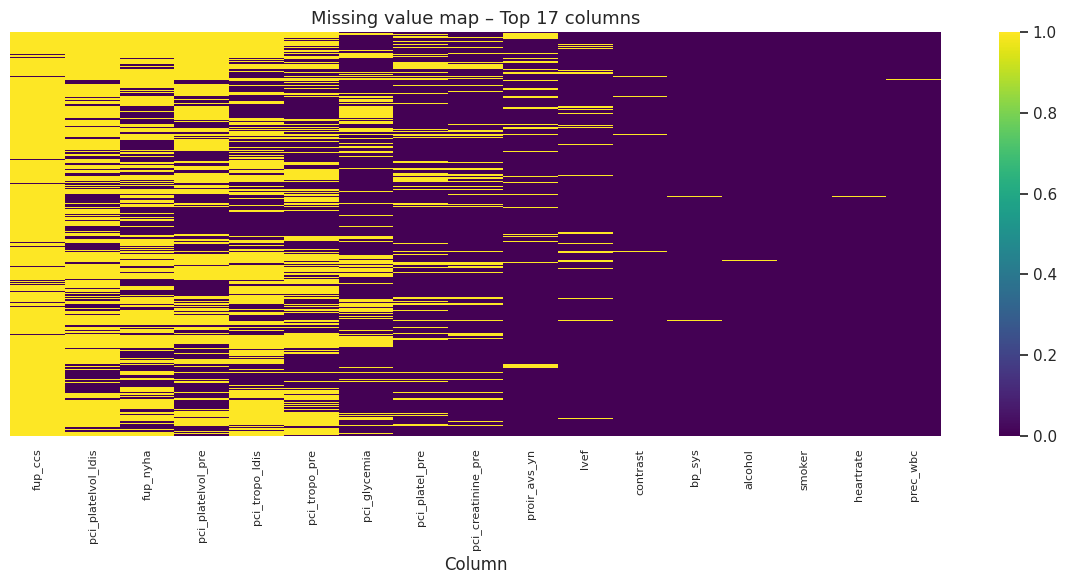

In [8]:
# Heatmap of the 30 columns with most missing values – helps spot patterns (e.g. data missing together)
top_missing_cols = missing_df.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    df[top_missing_cols].isna(),
    yticklabels=False,
    cbar=True,
    ax=ax,
    cmap='viridis',
)
ax.set_title(f'Missing value map – Top {len(top_missing_cols)} columns', fontsize=13)
ax.set_xlabel('Column')
ax.tick_params(axis='x', rotation=90, labelsize=8)
plt.tight_layout()
plt.show()

In [9]:
df.isna().sum().sort_values(ascending=False).head(17)

fup_ccs               4382
pci_platelvol_ldis    3273
fup_nyha              2736
pci_platelvol_pre     2550
pci_tropo_ldis        2544
pci_tropo_pre         2257
pci_glycemia          1290
pci_platel_pre         892
pci_creatinine_pre     832
proir_avs_yn           459
lvef                   282
contrast                41
bp_sys                  17
alcohol                 16
smoker                  13
heartrate                9
prec_wbc                 1
dtype: int64

## 6. Descriptive statistics

Summary of numerical and categorical variables.

In [10]:
# Statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mnppid,4579.00,49472.37,16819.73,15063.00,36015.50,47849.00,63008.50,83388.00
mnpctrid,4579.00,1284.81,997.89,341.00,441.00,1081.00,1742.00,4901.00
cec_barc235_335d,4579.00,0.08,0.27,0.00,0.00,0.00,0.00,1.00
cec_cvdeath_335d,4579.00,0.02,0.13,0.00,0.00,0.00,0.00,1.00
cec_mi_335d,4579.00,0.02,0.15,0.00,0.00,0.00,0.00,1.00
cec_stroke_335d,4579.00,0.01,0.09,0.00,0.00,0.00,0.00,1.00
cec_bleed_335d,4579.00,0.11,0.31,0.00,0.00,0.00,0.00,1.00
cec_barc2_335d,4579.00,0.06,0.23,0.00,0.00,0.00,0.00,1.00
cec_barc3_335d,4579.00,0.02,0.15,0.00,0.00,0.00,0.00,1.00
cec_barc35_335d,4579.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00


In [11]:
# Frequencies for categorical variables (object)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False))


--- randomized_pop ---
randomized_pop
randomised    4579
Name: count, dtype: int64

--- mnpaid ---
mnpaid
0634-973-01-0008    1
0634-031-01-0002    1
0634-031-01-0003    1
0634-972-05-0006    1
0634-972-05-0007    1
                   ..
0634-031-01-0012    1
0634-031-01-0015    1
0634-031-01-0016    1
0634-031-01-0017    1
0634-031-01-0019    1
Name: count, Length: 4579, dtype: int64

--- mnpctrname ---
mnpctrname
634 - Switzerland, Bern, Inselspital                                 308
634 - Estonia, Tallinn, North-Estonia Medical Centre Foundation      259
634 - The Netherlands, Rotterdam, Maasstad Ziekenhuis                233
634 - France, Massy, Hopital Prive Jacques Cartier                   129
634 - France, Montauban, Clinique du Pont de Chaume                  124
                                                                    ... 
634 - UK, Derry, Altnagelvin Hospital                                  2
634 - The Netherlands, Den Haag, Hagahospital                        

## 7. Outcome variables (`cec_` prefix)

The `cec_*_335d` columns are clinical endpoints measured at **335 days** from randomisation.
They come in two types:
- **Binary flags** (`cec_*_335d`): 1 = event occurred, 0 = no event
- **Time to event** (`cec_*_335d_days`): days until the event or end of follow-up

In [12]:
# Event rate (%) for each binary endpoint
cec_binary = [c for c in df.columns if c.startswith('cec_') and not c.endswith('_days')]

event_rates = (df[cec_binary].mean() * 100).sort_values(ascending=False).round(2)
event_rates.rename('event_rate_%').to_frame()

,event_rate_%
cec_bleed_335d,11.05
cec_barc235_335d,7.84
cec_barc2_335d,5.55
cec_revasc_335d,3.54
cec_barc35_335d,2.66
cec_barc3_335d,2.45
cec_mi_335d,2.38
cec_cvdeath_335d,1.77
cec_stroke_335d,0.76


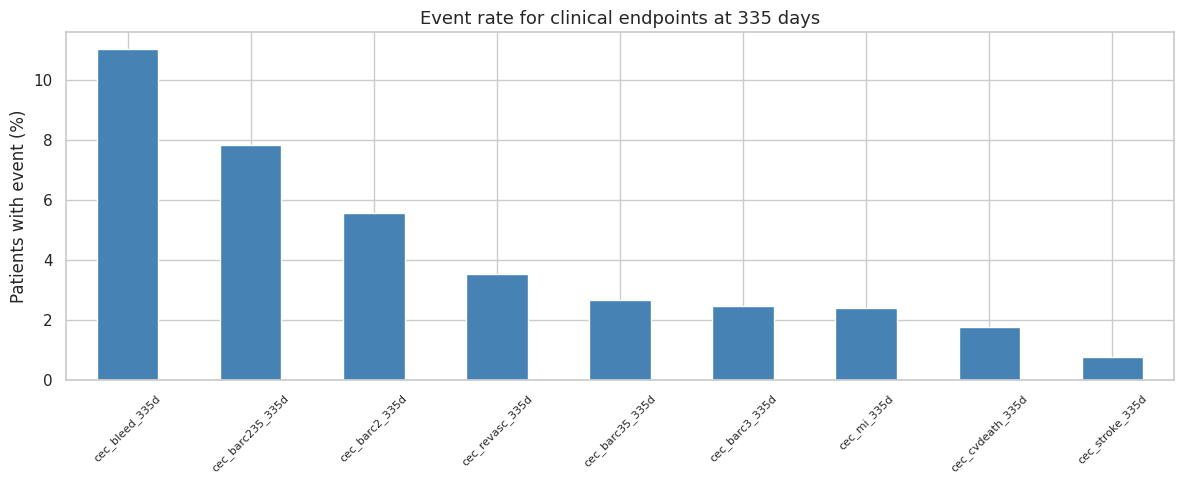

In [13]:
# Bar plot of event rates for the main endpoints
fig, ax = plt.subplots(figsize=(12, 5))
event_rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Event rate for clinical endpoints at 335 days', fontsize=13)
ax.set_ylabel('Patients with event (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

## 8. Key clinical variables

Distributions of the most relevant baseline variables for the project.

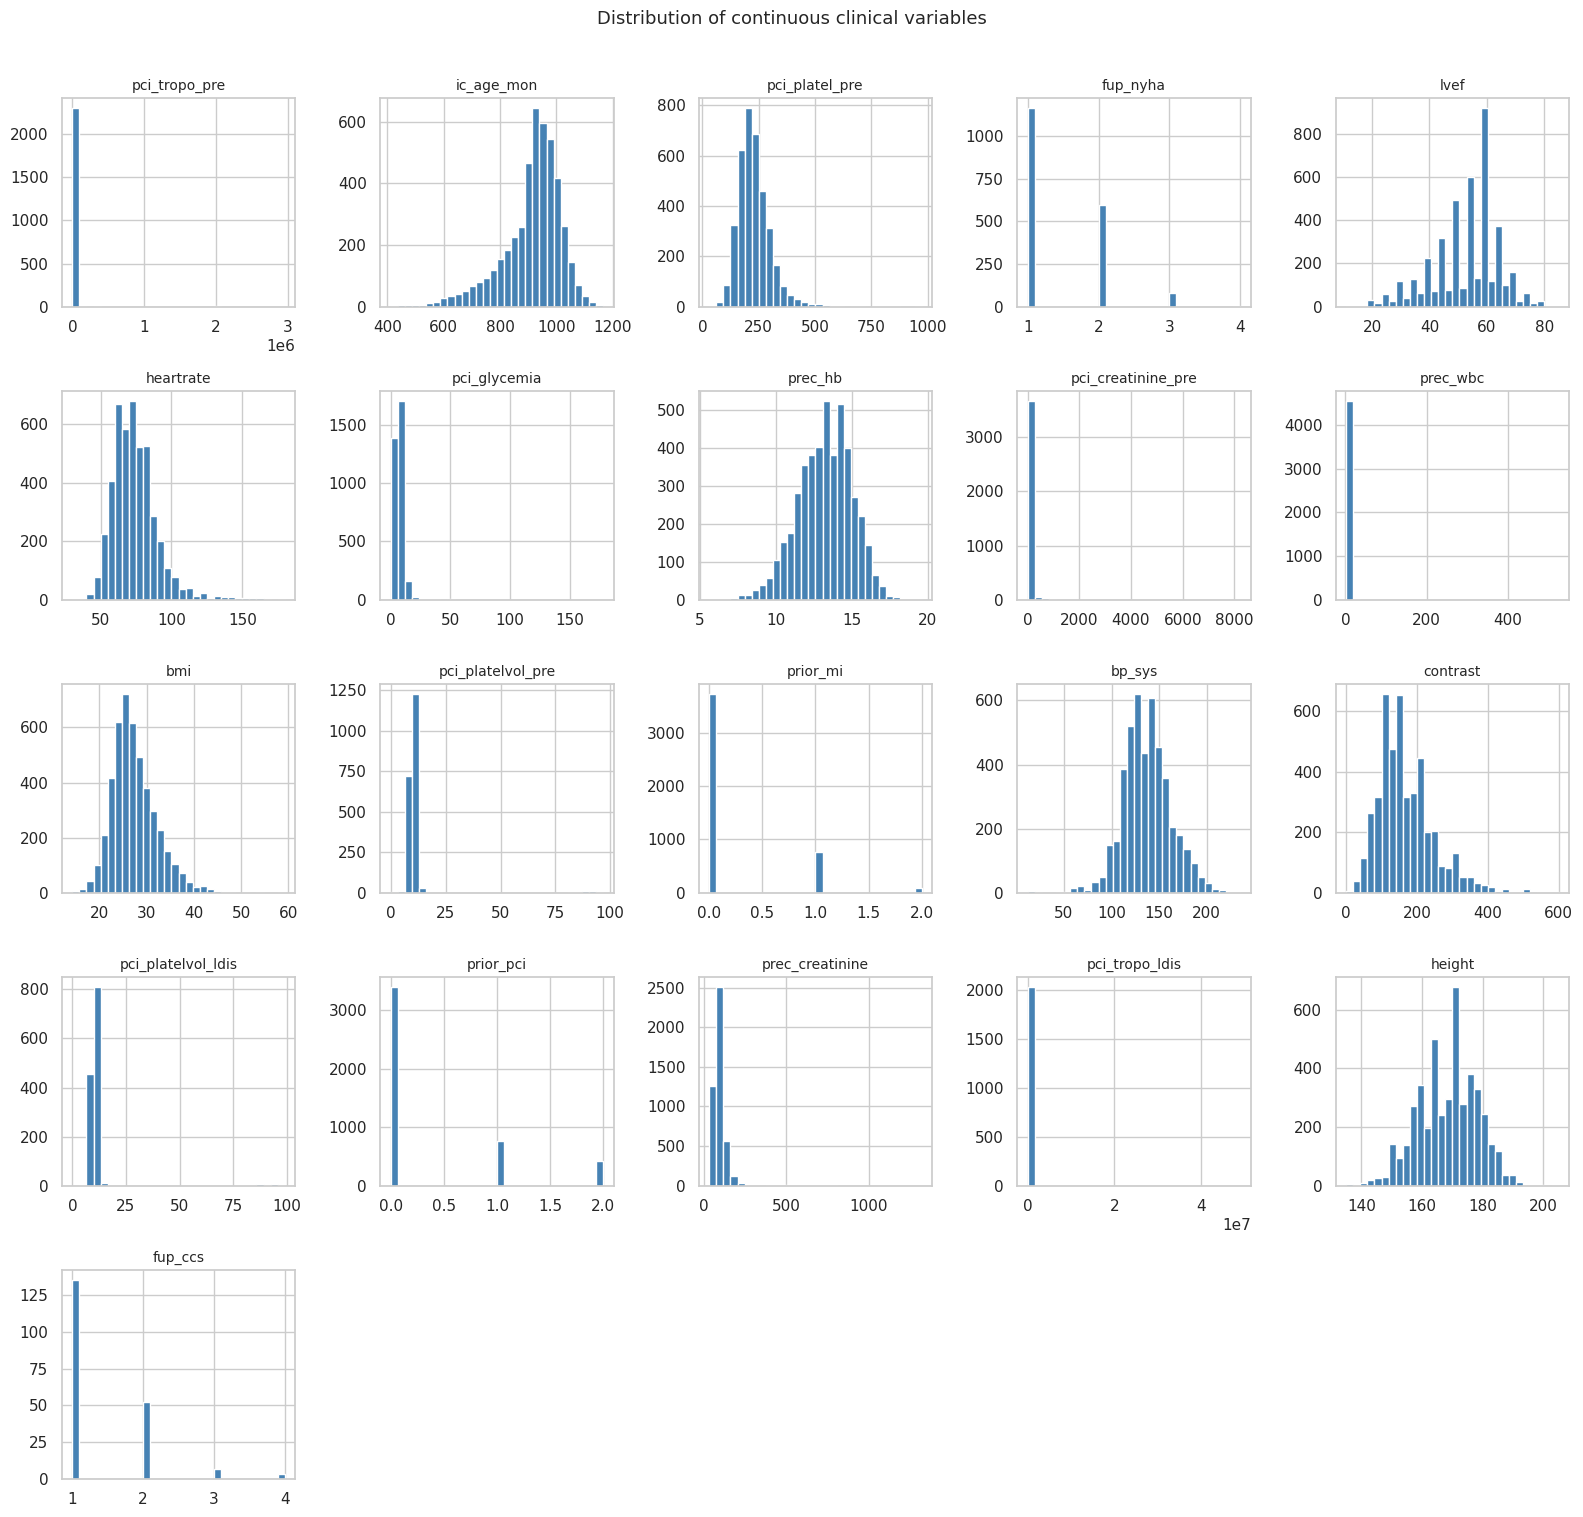

In [14]:
from data.schema_selected import numeric

# Keep only those actually present in the dataset
key_continuous = [c for c in numeric if c in df.columns]

n_cols = 5
n_rows = -(-len(key_continuous) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_continuous):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Hide any empty subplots
for j in range(len(key_continuous), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of continuous clinical variables', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Categorical variables (`category` dtype)

Section 6 only covered the `object` columns (mostly identifiers and centre metadata).
The variables listed in `categorical` (from `data/schema_selected.py`) are stored as
pandas `category` dtype and are the clinically meaningful categorical features
(comorbidities, risk factors, demographics).

In [15]:
from data.schema_selected import categorical

# Frequencies for the clinically relevant categorical variables
for col in categorical:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False))


--- afib ---
afib
no                                3089
yes - paroxysmal                   803
yes - permanent                    371
yes - persistent                   241
yes - long-standing persistent      75
Name: count, dtype: int64

--- alcohol ---
alcohol
never                                                 2383
yes - less than eight beers or equivalent per week    1250
unknown - the patient does not want to answer          557
yes - eight beers and equivalent per week or more      190
yes - unknown consumption per week                     183
NaN                                                     16
Name: count, dtype: int64

--- diabetes ---
diabetes
no                                3041
type II oral drugs                 944
type II insulin and oral drugs     219
type II insulin                    185
type II diet                       152
type I-insulin dependent            38
Name: count, dtype: int64

--- geography ---
geography
Europe                 3838
Asia       

/tmp/ipykernel_1002369/257263922.py:21: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


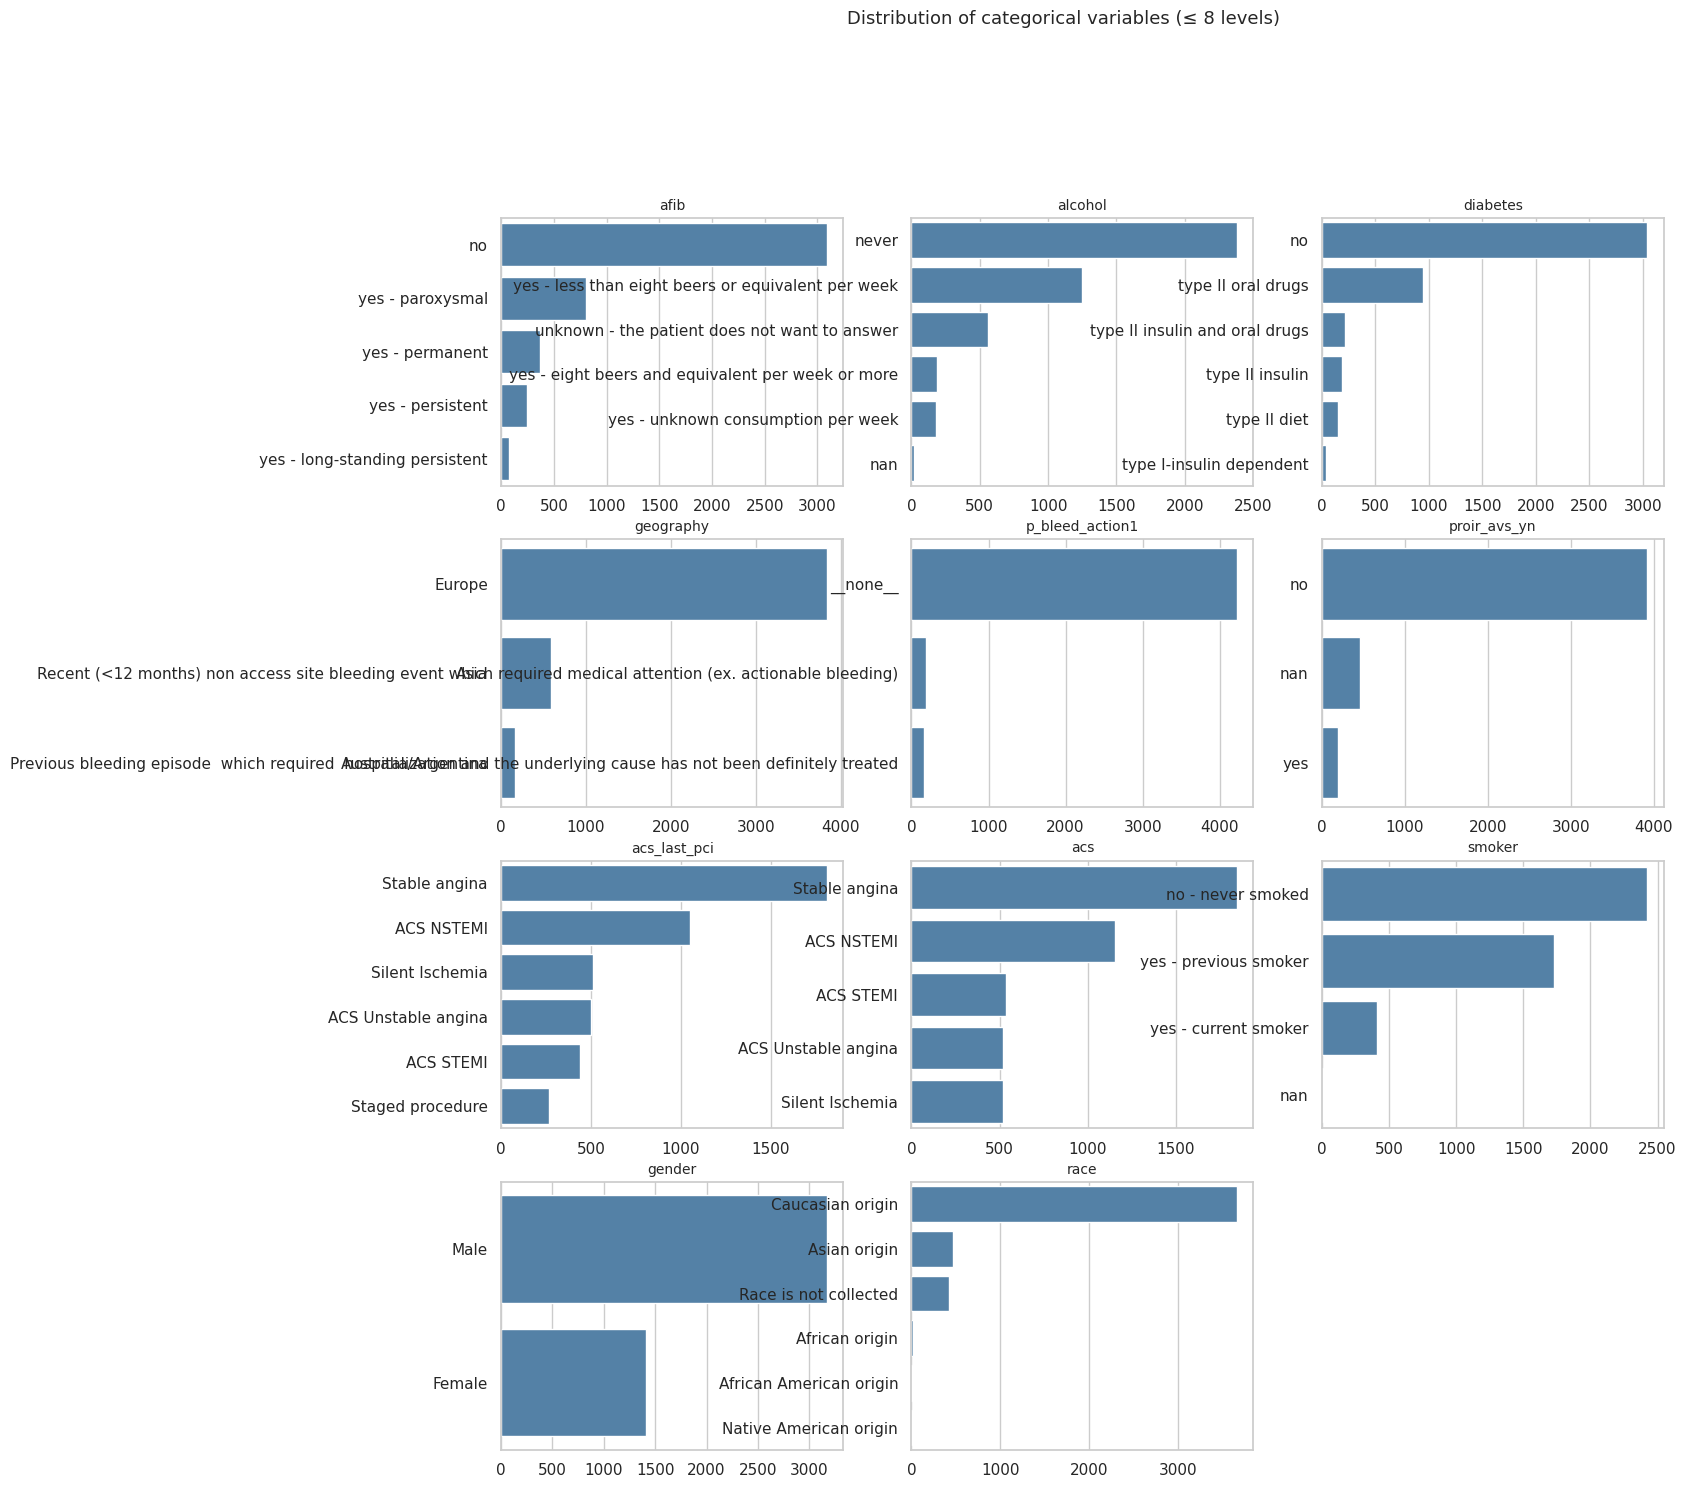

In [16]:
# Bar charts for categorical variables with a manageable number of levels
plot_cols = [c for c in categorical if df[c].nunique(dropna=False) <= 8]

n_cols = 3
n_rows = -(-len(plot_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    counts = df[col].value_counts(dropna=False)
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of categorical variables (≤ 8 levels)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Outcome variables – deeper look

Section 7 showed the marginal event rate for each `cec_*_335d` endpoint. Two things
matter for the modelling stage:

1. **Class imbalance** – the rarest endpoints (`cec_stroke_335d`, `cec_cvdeath_335d`)
   have well under 2% positive cases, which has direct consequences for model choice,
   evaluation metrics, and resampling strategy.
2. **Overlap between endpoints** – several `cec_*` columns are *composite* endpoints
   (e.g. `cec_barc235_335d`, `cec_barc35_335d`) built from the others, so they are not
   independent targets. Understanding the overlap avoids leakage if more than one
   endpoint is used as a target.

Note: this dataset does not contain the `cec_*_335d_days` time-to-event columns
mentioned in the prefix table above – only the binary flags are available here.

In [17]:
# How many patients experience at least one of the 9 clinical endpoints?
n_any_event = (df[cec_binary].sum(axis=1) > 0).sum()
print(f'Patients with at least one cec_ event: {n_any_event} / {len(df)} '
      f'({n_any_event / len(df) * 100:.2f}%)')

# Distribution of the number of simultaneous endpoints flagged per patient
n_events_per_patient = df[cec_binary].sum(axis=1)
n_events_per_patient.value_counts().sort_index().rename('n_patients').to_frame()

Patients with at least one cec_ event: 739 / 4579 (16.14%)


,n_patients
0,3840
1,313
2,64
3,211
4,102
5,40
6,5
7,4


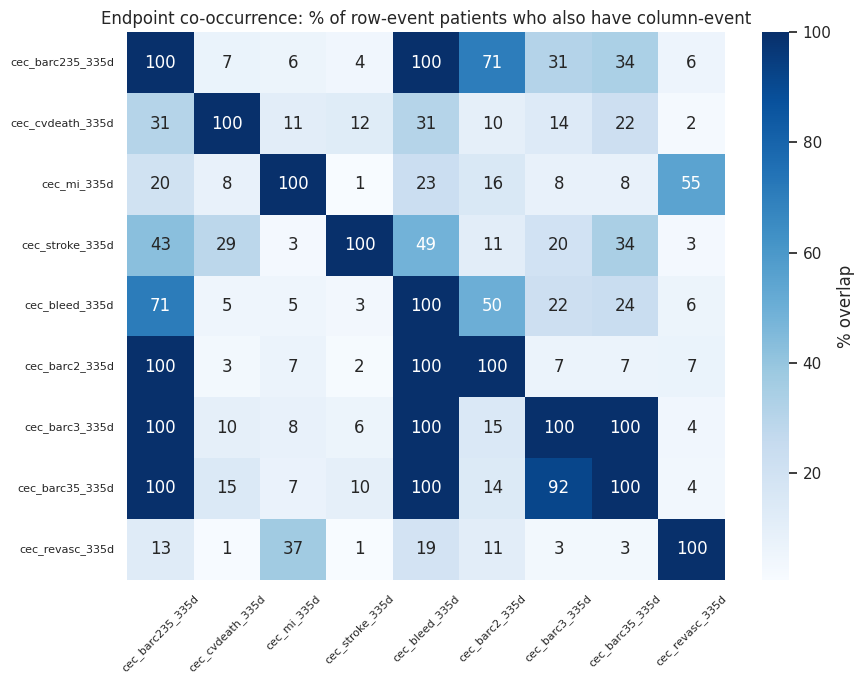

In [18]:
# Co-occurrence heatmap between cec_ endpoints
# Diagonal = event rate; off-diagonal = % of patients with event A who also have event B
cooccurrence = pd.DataFrame(index=cec_binary, columns=cec_binary, dtype=float)

for a in cec_binary:
    mask_a = df[a] == 1
    for b in cec_binary:
        cooccurrence.loc[a, b] = df.loc[mask_a, b].mean() * 100 if mask_a.sum() > 0 else np.nan

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cooccurrence, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% overlap'}, ax=ax)
ax.set_title('Endpoint co-occurrence: % of row-event patients who also have column-event', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

## 11. Treatment regimen vs. clinical outcomes

The core comparison of the trial is **abbreviated vs. prolonged DAPT**
(`mnp_regimen_gr`). This section checks:

- whether `mnp_regimen_gr` and `regimen` carry the same information (redundant column),
- how the randomisation groups are balanced,
- and how event rates differ between the two arms for each `cec_*` endpoint.

In [19]:
# Check if 'mnp_regimen_gr' and 'regimen' are duplicate encodings of the same information
pd.crosstab(df['mnp_regimen_gr'], df['regimen'])

regimen,abbreviated DAPT,prolonged DAPT
mnp_regimen_gr,,
abbreviated DAPT,2295,0
prolonged DAPT,0,2284


In [20]:
# Event rate (%) per clinical endpoint, split by treatment regimen
rates_by_regimen = (
    df.groupby('mnp_regimen_gr')[cec_binary]
    .mean()
    .T
    .mul(100)
    .round(2)
)
rates_by_regimen['diff (abbreviated - prolonged)'] = (
    rates_by_regimen['abbreviated DAPT'] - rates_by_regimen['prolonged DAPT']
).round(2)
rates_by_regimen.sort_values('diff (abbreviated - prolonged)', ascending=False)

mnp_regimen_gr,abbreviated DAPT,prolonged DAPT,diff (abbreviated - prolonged)
cec_mi_335d,2.61,2.15,0.46
cec_revasc_335d,3.49,3.59,-0.10
cec_barc3_335d,2.31,2.58,-0.27
cec_cvdeath_335d,1.61,1.93,-0.32
cec_stroke_335d,0.52,1.01,-0.49
cec_barc35_335d,2.40,2.93,-0.53
cec_barc2_335d,4.44,6.65,-2.21
cec_barc235_335d,6.45,9.24,-2.79
cec_bleed_335d,8.80,13.31,-4.51


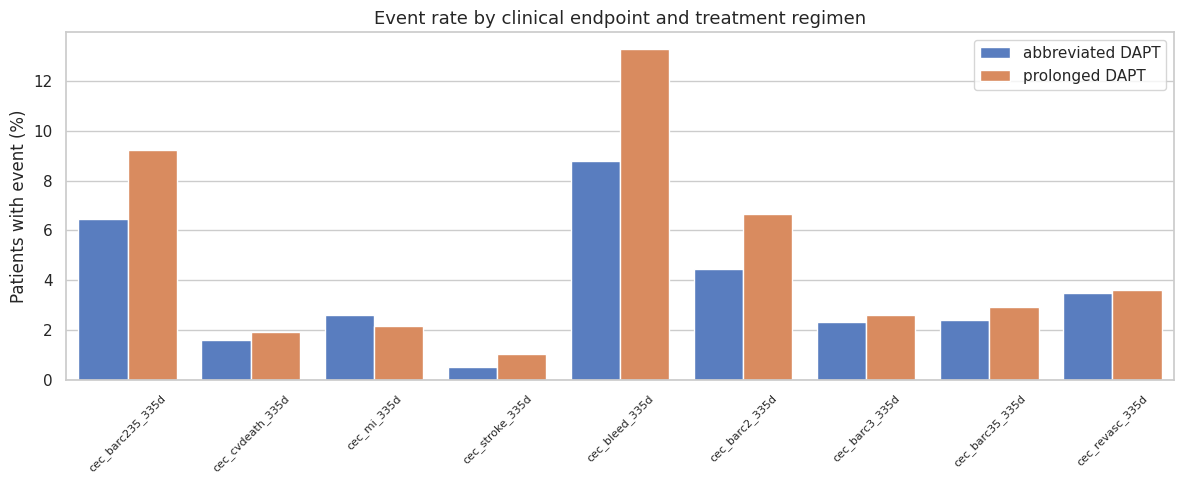

In [21]:
# Grouped bar plot: event rate by endpoint and regimen
plot_df = rates_by_regimen[['abbreviated DAPT', 'prolonged DAPT']].reset_index().melt(
    id_vars='index', var_name='regimen', value_name='event_rate_%'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x='index', y='event_rate_%', hue='regimen', ax=ax)
ax.set_title('Event rate by clinical endpoint and treatment regimen', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Patients with event (%)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend(title='')
plt.tight_layout()
plt.show()

## 12. Outlier and data-quality screening

The descriptive statistics in Section 6 already hinted at extreme max values
(e.g. `pci_tropo_pre` up to ~3,000,000, `pci_tropo_ldis` up to ~49,000,000,
`pci_creatinine_pre` up to ~8,200, `prec_wbc` up to 526). These are most likely
unit-mixing issues (e.g. ng/L vs µg/L for troponin) or transcription errors rather
than plausible clinical values, and should be addressed in `01_data_cleaning.ipynb`.

This section quantifies how many values per column fall far outside the
typical (IQR-based) range, to prioritise which columns need closer inspection.

In [22]:
# IQR-based outlier count (values beyond 3x IQR from Q1/Q3 - "extreme" outliers)
# for the continuous clinical variables
outlier_rows = []
for col in key_continuous:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_rows.append({
        'column': col,
        'n_extreme_outliers': n_outliers,
        'pct_extreme_outliers': round(n_outliers / len(s) * 100, 2),
        'normal_range': f'[{lower:.1f}, {upper:.1f}]',
        'max_value': s.max(),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('n_extreme_outliers', ascending=False)
outlier_df[outlier_df['n_extreme_outliers'] > 0]

,column,n_extreme_outliers,pct_extreme_outliers,normal_range,max_value
12,prior_mi,864,18.87,"[0.0, 0.0]",2.00
0,pci_tropo_pre,330,14.21,"[-636.8, 883.2]",2960000.00
18,pci_tropo_ldis,228,11.20,"[-1594.7, 2218.9]",49059000.00
17,prec_creatinine,130,2.84,"[-30.0, 215.0]",1321.58
8,pci_creatinine_pre,114,3.04,"[-29.0, 216.0]",8221.20
6,pci_glycemia,79,2.40,"[-2.0, 15.3]",178.00
5,heartrate,48,1.05,"[8.0, 134.0]",180.00
11,pci_platelvol_pre,42,2.07,"[3.8, 16.4]",96.80
9,prec_wbc,40,0.87,"[-2.5, 18.0]",526.00
15,pci_platelvol_ldis,29,2.22,"[5.0, 15.5]",99.00


**Note:** `prior_mi` and `prior_pci` are mostly 0/1/2 count-like variables with an
IQR of 0, so the 3xIQR rule flags many valid values as "outliers" for them — this is
a false positive of the method, not a data quality issue. The genuinely concerning
columns are the lab values with implausible maxima: `pci_tropo_pre`, `pci_tropo_ldis`,
`pci_creatinine_pre`, `prec_creatinine`, `pci_glycemia` and `prec_wbc`.

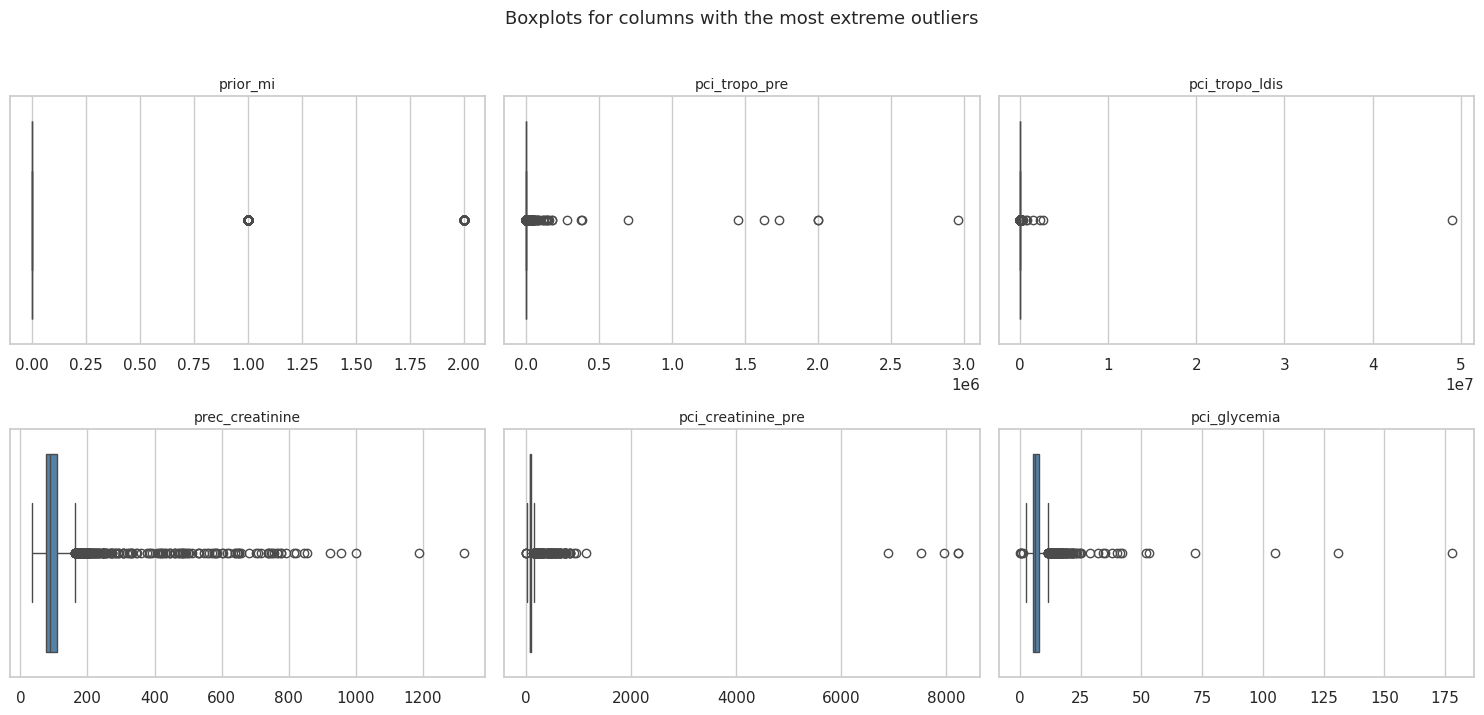

In [23]:
# Boxplots for the columns with the most extreme outliers - visualises the scale of the problem
top_outlier_cols = outlier_df.head(6)['column'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots for columns with the most extreme outliers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13. Correlation between numeric variables

Spearman correlation (robust to the outliers identified above and to the
non-normal distributions of several lab values) between the continuous
clinical variables. Useful to spot redundant features before modelling.

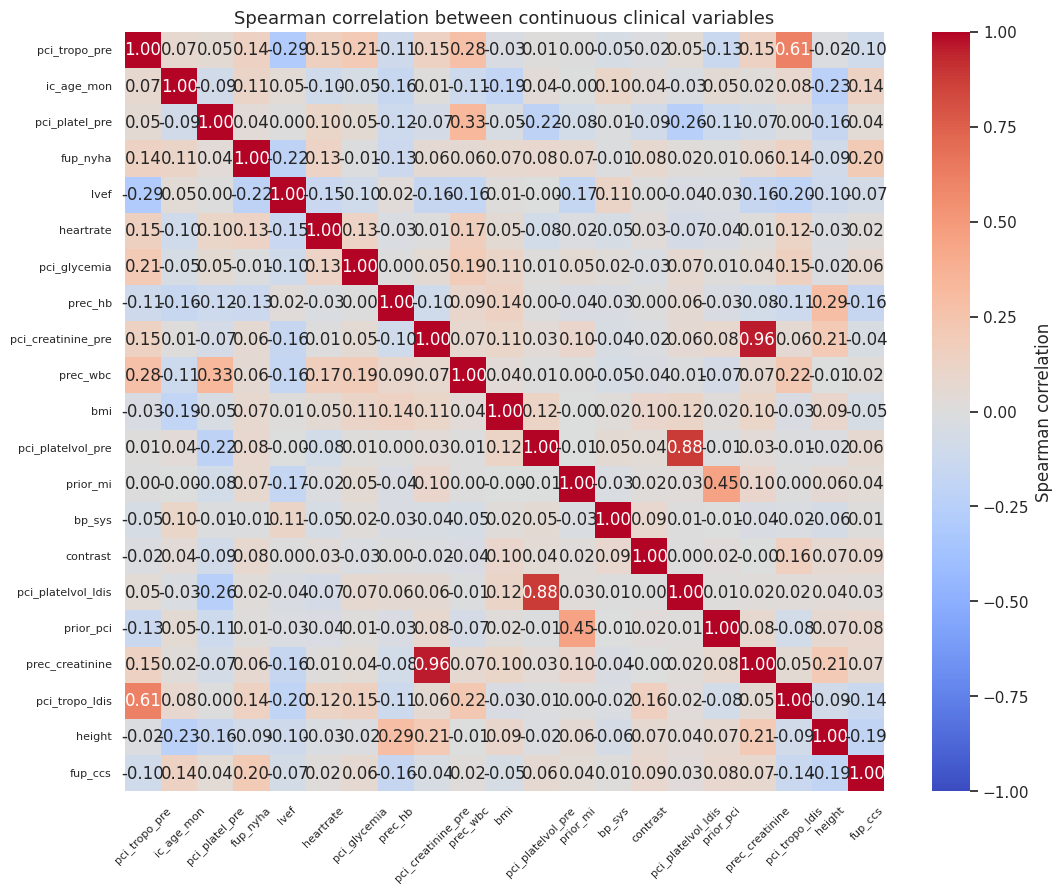

In [24]:
# Spearman correlation heatmap for the continuous clinical variables
corr = df[key_continuous].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'label': 'Spearman correlation'})
ax.set_title('Spearman correlation between continuous clinical variables', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

In [25]:
# List variable pairs with |correlation| above 0.6 - candidates for redundancy
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename('spearman_corr')
    .reset_index()
    .rename(columns={'level_0': 'var_1', 'level_1': 'var_2'})
)
pairs = pairs[pairs['spearman_corr'].abs() > 0.6].sort_values('spearman_corr', ascending=False)
pairs

,var_1,var_2,spearman_corr
140,pci_creatinine_pre,prec_creatinine,0.96
168,pci_platelvol_pre,pci_platelvol_ldis,0.88
17,pci_tropo_pre,pci_tropo_ldis,0.61


## 14. Summary

| Metric | Value |
|--------|-------|
| N patients | 4,579 |
| Total columns | 63 |
| Columns with missing values | 17 / 63 |
| Continuous clinical variables (`numeric`) | 21 |
| Categorical clinical variables (`categorical`) | 11 |
| Binary clinical variables (`binary`) | 14 |
| Clinical endpoints (`cec_*_335d`) | 9 |
| Patients with ≥1 clinical endpoint event | 739 / 4,579 (16.1%) |

**Key findings from this exploration:**

- All patients are classified as `randomised` in the `randomized_pop` column: no
  patients excluded before this step.
- The dataset does **not** contain the `cec_*_335d_days` time-to-event columns
  referenced in the column-group table (Section 4) – only binary endpoint flags
  are available.
- `mnp_regimen_gr` and `regimen` are **fully redundant** encodings of the treatment
  arm (Section 11) – one of them can be dropped during cleaning.
- The two treatment arms are well balanced (2,295 abbreviated vs. 2,284 prolonged
  DAPT), but clinical endpoints are **strongly imbalanced** (event rates from 0.76%
  to 11.05%), which should drive the choice of evaluation metric and resampling
  strategy for any predictive model.
- Composite endpoints (`cec_barc235_335d`, `cec_barc2_335d`, `cec_barc35_335d`,
  `cec_barc3_335d`) overlap heavily with their components (Section 10) – care is
  needed if more than one is used as a modelling target.
- Abbreviated DAPT shows a **lower bleeding rate** (8.80% vs. 13.31% for
  `cec_bleed_335d`) but a slightly **higher MI rate** (2.61% vs. 2.15%) than
  prolonged DAPT – consistent with the expected ischaemia/bleeding trade-off
  (Section 11).
- Several lab variables contain **implausible extreme values**
  (`pci_tropo_pre` up to ~3,000,000, `pci_tropo_ldis` up to ~49,000,000,
  `pci_creatinine_pre` up to ~8,200, `prec_creatinine` up to ~1,300,
  `prec_wbc` up to 526) – likely unit-mixing or transcription errors that need
  capping/correction (Section 12).
- `pci_creatinine_pre` and `prec_creatinine` are highly correlated (Spearman
  ρ = 0.96), and `pci_platelvol_pre`/`pci_platelvol_ldis` (ρ = 0.88) – candidates
  for redundancy reduction (Section 13).
- Missingness is concentrated in `pci_*` and `fup_*` variables, with `fup_ccs`
  (95.7%) and `pci_platelvol_ldis` (71.5%) the most affected – likely structurally
  missing (only recorded for a subset of procedures/visits) rather than random.

The next step (`01_data_cleaning.ipynb`) will handle missing values, outlier
correction, redundant-column removal, and encoding of categorical variables.